# Run an SVD analysis for snow-covered April 1 SWE from the UCLA WUS Reanalysis dataset:  
testing on raw SWE values, SWE anomalies, and SWE standardized anomalies

In [33]:
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import altair as alt
import pickle
from scipy.linalg import svd
import seaborn as sns

### Load Data:

In [34]:
sierras = gpd.read_file('../data/misc/sierra_simplified.geojson')

In [35]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Clip to simplified Sierra gmba polygon:

In [36]:
swe_sca_ds_allyrs_sierras = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

### Get just April 1 of each year from the timeseries:

In [37]:
# 1. Select April 1 of each year
swe_allyrs_april1 = swe_sca_ds_allyrs_sierras.SWE_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

In [38]:
swe_allyrs_april1_snowy = swe_allyrs_april1.where(swe_allyrs_april1.mean(dim='time') > 0.1)

### Stack the space dimension and remove nan values:

In [39]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d = swe_allyrs_april1_snowy.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean = swe_2d.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array = swe_2d_clean.values

In [9]:
swe_2d

<xarray.DataArray 'SWE_Post' (time: 37, space: 1164373)> Size: 172MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(37, 1164373), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * space        (space) object 9MB MultiIndex
  * y            (space) float32 5MB 34.82 34.82 34.82 ... 40.45 40.45 40.45
  * x            (space) float32 5MB -121.9 -121.9 -121.9 ... -117.9 -117.9
Attributes:
    Units:    meters

### Run the SVD on SWE values (no anomaly calculation has happened yet):

In [10]:
U, S, V = svd(swe_2d_array.T, full_matrices=False)

In [11]:
swe_2d_array.T.shape

(117133, 37)

In [12]:
U.shape

(117133, 37)

In [13]:
swe_2d_array.shape

(37, 117133)

In [14]:
U.T.shape

(37, 117133)

In [15]:
V.shape

(37, 37)

In [16]:
V

array([[-0.15653835, -0.24219656, -0.08959656, ..., -0.24981484,
        -0.08893249, -0.08905299],
       [ 0.07534568,  0.28649408,  0.12205446, ..., -0.1729456 ,
         0.1051219 ,  0.10441726],
       [ 0.15959255,  0.43819445, -0.0049364 , ..., -0.17260188,
        -0.1939488 , -0.21586023],
       ...,
       [ 0.00899539, -0.01020894, -0.00894591, ...,  0.01200937,
         0.09788828,  0.06769232],
       [-0.01672169,  0.01919649,  0.02848263, ..., -0.02593645,
         0.13234279, -0.10119605],
       [ 0.00674082,  0.02116148,  0.03091111, ..., -0.00448268,
         0.04346185,  0.04215471]], shape=(37, 37), dtype=float32)

In [17]:
V.T

array([[-0.15653835,  0.07534568,  0.15959255, ...,  0.00899539,
        -0.01672169,  0.00674082],
       [-0.24219656,  0.28649408,  0.43819445, ..., -0.01020894,
         0.01919649,  0.02116148],
       [-0.08959656,  0.12205446, -0.0049364 , ..., -0.00894591,
         0.02848263,  0.03091111],
       ...,
       [-0.24981484, -0.1729456 , -0.17260188, ...,  0.01200937,
        -0.02593645, -0.00448268],
       [-0.08893249,  0.1051219 , -0.1939488 , ...,  0.09788828,
         0.13234279,  0.04346185],
       [-0.08905299,  0.10441726, -0.21586023, ...,  0.06769232,
        -0.10119605,  0.04215471]], shape=(37, 37), dtype=float32)

### Format the spatial matrix with coordinates:

In [18]:
U_spatial = xr.full_like(swe_2d_clean, np.nan)
U_spatial.values = U.T
U_spatial_unstacked = U_spatial.unstack('space')
U_spatial_unstacked_sorted = U_spatial_unstacked.sortby(['y', 'x'])

### Replace the time coordinate with EOF number:

In [19]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted.sizes['time']
U_spatial_eof = U_spatial_unstacked_sorted.copy()
U_spatial_eof = U_spatial_eof.rename({'time': 'EOF'})
U_spatial_eof = U_spatial_eof.assign_coords(EOF=np.arange(1, n_eof+1))
U_spatial_eof

<xarray.DataArray 'SWE_Post' (EOF: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37
Attributes:
    Units:    meters

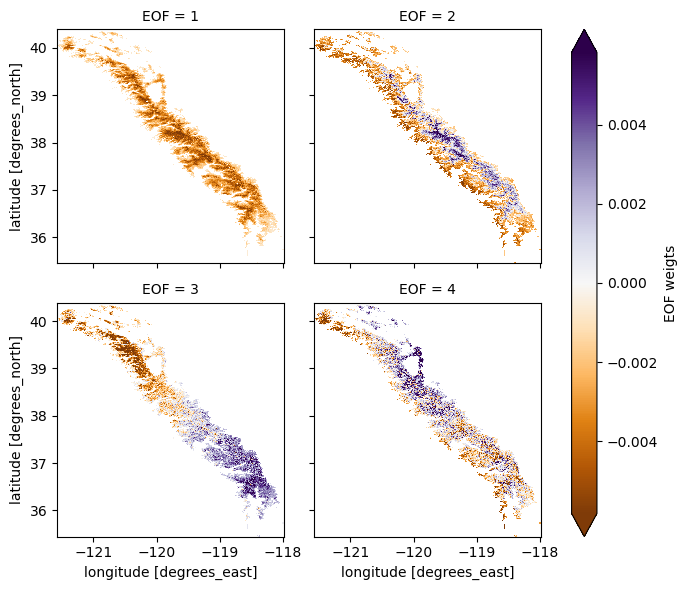

In [20]:
firstFour = U_spatial_eof.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

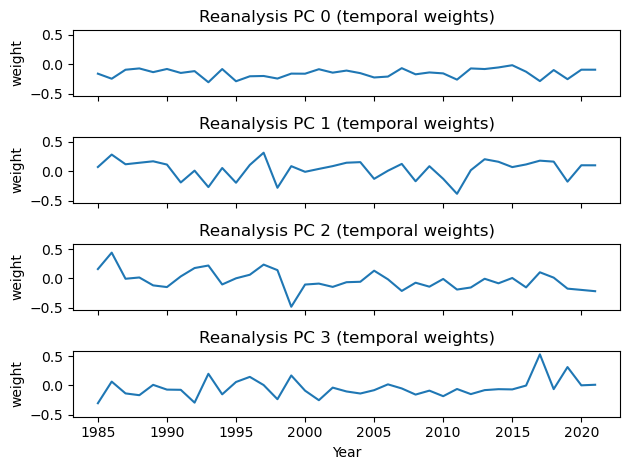

In [21]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=True, sharey=True)
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i} (temporal weights)')
    i+=1
ax[3].set_xlabel('Year')
plt.tight_layout()

In [22]:
# SVD Variance Explained, divide S values by the sum of all S
var_exp = S / np.sum(S)

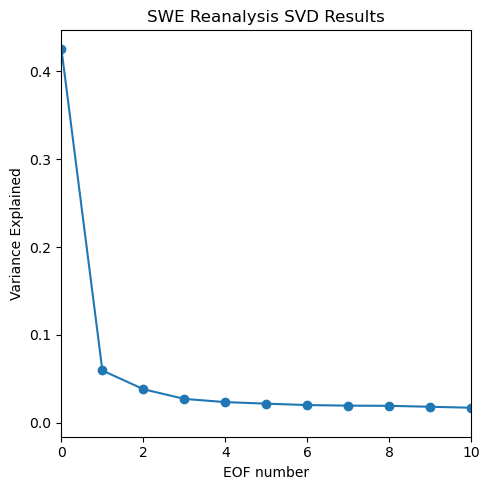

In [23]:
plt.figure(figsize=(5,5))
plt.plot(var_exp,'-o')
plt.xlabel('EOF number')
plt.ylabel('Variance Explained')
#plt.title('SVD Variance Explained')
#plt.ylim([0,0.16])
plt.xlim([0,10])
plt.title('SWE Reanalysis SVD Results')
plt.tight_layout()

In [24]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 3 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:3]),1)), '\nthe top 2 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:2]),1)), '\nthe top 1 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:1]),1)))


Percent of overall variance explained by 
the top 3 patterns = 52.29999923706055% 
the top 2 patterns = 48.5% 
the top 1 patterns = 42.599998474121094%


In [25]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 10 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:10]),1)), '\nthe top 4 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:4]),1)), '\nthe top 5 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:5]),1)), '\nthe top 7 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:7]),1)))


Percent of overall variance explained by 
the top 10 patterns = 67.4000015258789% 
the top 4 patterns = 55.099998474121094% 
the top 5 patterns = 57.400001525878906% 
the top 7 patterns = 61.599998474121094%


## Repeat but for the SWE standardized anomalies:

In [40]:
swe_allyrs_april1_snowy_anomalies = (swe_allyrs_april1_snowy - swe_allyrs_april1_snowy.mean(dim='time')) / swe_allyrs_april1_snowy.std(dim='time')

### Stack the space dimension and remove nan values:

In [41]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d_anom = swe_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean_anom = swe_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array_anom = swe_2d_clean_anom.values

In [28]:
swe_2d

<xarray.DataArray 'SWE_Post' (time: 37, space: 1164373)> Size: 172MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(37, 1164373), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * space        (space) object 9MB MultiIndex
  * y            (space) float32 5MB 34.82 34.82 34.82 ... 40.45 40.45 40.45
  * x            (space) float32 5MB -121.9 -121.9 -121.9 ... -117.9 -117.9
Attributes:
    Units:    meters

### Run the SVD on the standardized anomalies:

In [42]:
U_anom, S_anom, V_anom = svd(swe_2d_array_anom.T, full_matrices=False)

In [49]:
U_anom_full, S_anom_full, V_anom_full = svd(swe_2d_array_anom.T, full_matrices=True)

ValueError: Indexing a matrix size 117133 x 117133 would incur integer overflow in LAPACK. Try using numpy.linalg.svd instead.

In [48]:
swe_2d_array_anom.T

array([[-0.17650634, -0.7340078 , -0.7340078 , ...,  0.8998129 ,
        -0.18902168, -0.6350229 ],
       [ 0.43135118, -0.82978386, -0.39933655, ...,  1.2825365 ,
        -0.17710063, -0.77584314],
       [-0.23718005, -0.64026284, -0.63946146, ...,  0.7973724 ,
        -0.21634473, -0.58496916],
       ...,
       [-0.89181405, -0.89737755, -0.89737755, ...,  1.599243  ,
        -0.41335303, -0.893205  ],
       [-0.69852334, -1.0469518 , -0.6846479 , ...,  0.03533469,
        -0.5859779 , -0.00937521],
       [-0.73611736, -0.82461894, -0.8571563 , ..., -0.3131322 ,
        -0.10619478, -0.8571563 ]], shape=(117133, 37), dtype=float32)

In [30]:
U_anom.shape

(117133, 37)

In [56]:
S_anom.shape

(37,)

In [57]:
V_anom.shape

(37, 37)

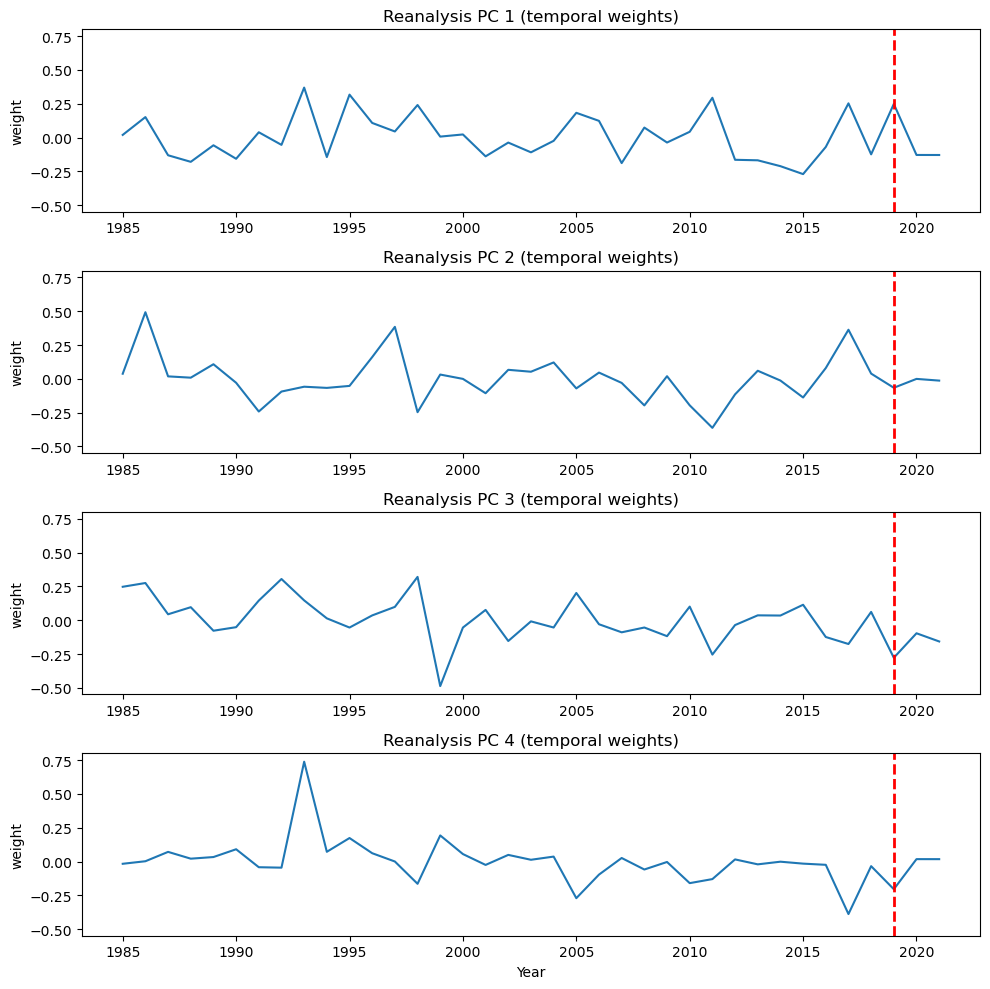

In [ ]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

### Format the spatial matrix with coordinates:

In [43]:
U_spatial_anom = xr.full_like(swe_2d_clean_anom, np.nan)
U_spatial_anom.values = U_anom.T
U_spatial_unstacked_anom = U_spatial_anom.unstack('space')
U_spatial_unstacked_sorted_anom = U_spatial_unstacked_anom.sortby(['y', 'x'])

In [51]:
U_spatial_anom = xr.full_like(swe_2d_clean_anom.T, np.nan)
U_spatial_anom.values = U_anom
U_spatial_unstacked_anom = U_spatial_anom.unstack('space')
U_spatial_unstacked_sorted_anom = U_spatial_unstacked_anom.sortby(['y', 'x'])

In [52]:
U_spatial_unstacked_sorted_anom

<xarray.DataArray 'SWE_Post' (time: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0

### Replace the time coordinate with EOF number:

In [53]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom.sizes['time']
U_spatial_eof_anom = U_spatial_unstacked_sorted_anom.copy()
U_spatial_eof_anom = U_spatial_eof_anom.rename({'time': 'EOF'})
U_spatial_eof_anom = U_spatial_eof_anom.assign_coords(EOF=np.arange(1, n_eof+1))
U_spatial_eof_anom

<xarray.DataArray 'SWE_Post' (EOF: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37

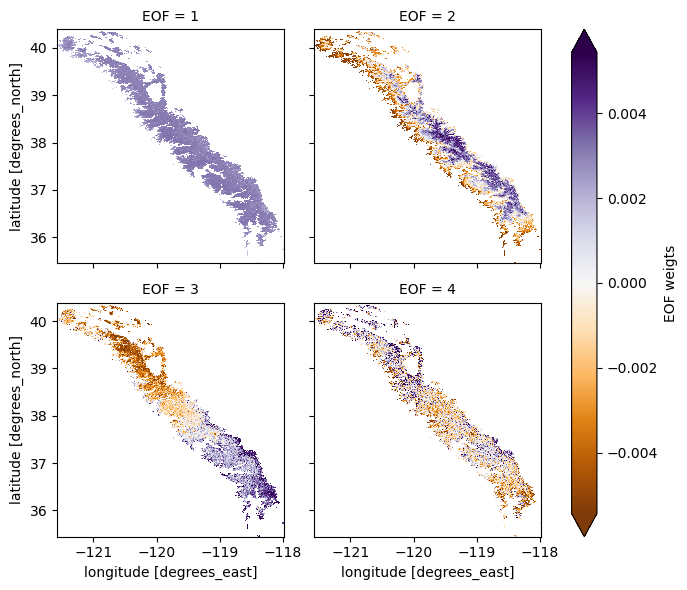

In [54]:
firstFour = U_spatial_eof_anom.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

In [77]:
U_spatial_eof_anom

<xarray.DataArray 'SWE_Post' (EOF: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37

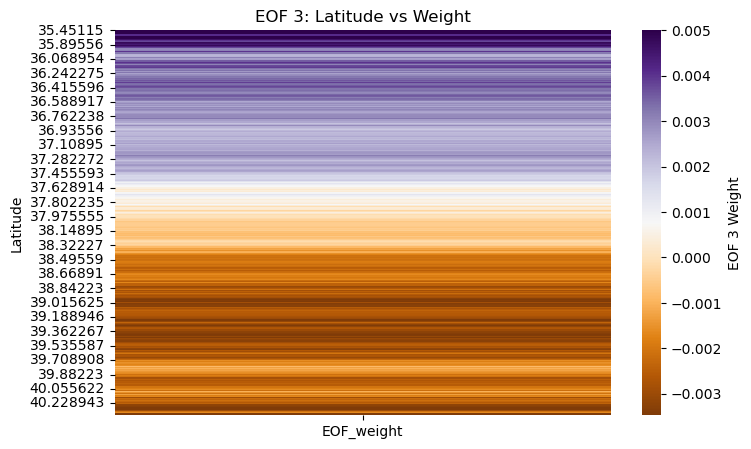

In [78]:


# Select EOF 3 (Python is 0-indexed, so EOF=3 is index 2)
eof3 = U_spatial_eof_anom.sel(EOF=3)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof3.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='y', values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    cbar_kws={'label': 'EOF 3 Weight'}
)
plt.title('EOF 3: Latitude vs Weight')
plt.ylabel('Latitude')
plt.xlabel('')
plt.show()

In [153]:
V_anom.shape

(37, 37)

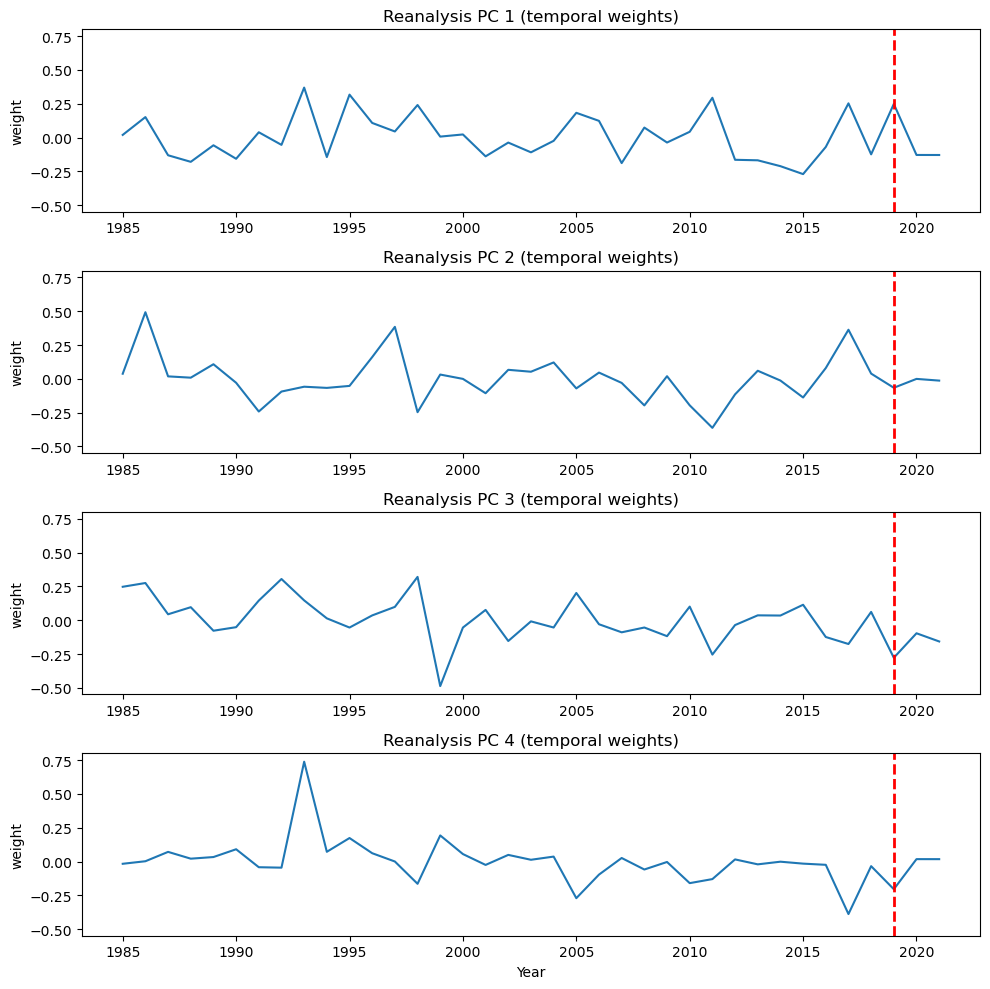

In [128]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

In [45]:
# SVD Variance Explained, divide S values by the sum of all S
var_exp = S_anom / np.sum(S_anom)

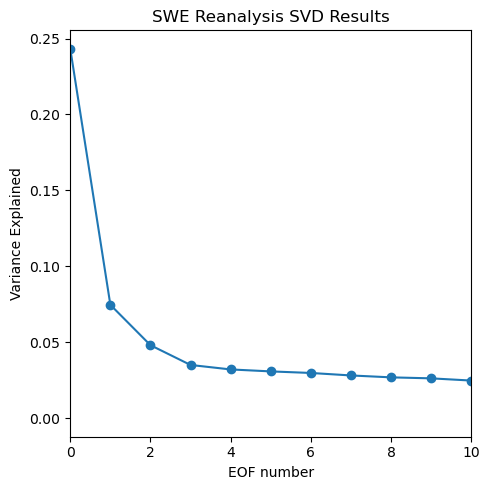

In [46]:
plt.figure(figsize=(5,5))
plt.plot(var_exp,'-o')
plt.xlabel('EOF number')
plt.ylabel('Variance Explained')
#plt.title('SVD Variance Explained')
#plt.ylim([0,0.16])
plt.xlim([0,10])
plt.title('SWE Reanalysis SVD Results')
plt.tight_layout()

In [151]:
S_anom.T.shape

(37,)

In [141]:
S_anom.T

array([1.78120361e+03, 5.46827209e+02, 3.52252441e+02, 2.56910980e+02,
       2.35367889e+02, 2.25874344e+02, 2.18345886e+02, 2.06377670e+02,
       1.97171432e+02, 1.92389893e+02, 1.81732071e+02, 1.75305939e+02,
       1.64936249e+02, 1.59811172e+02, 1.55223679e+02, 1.51857117e+02,
       1.45745499e+02, 1.41941727e+02, 1.34490906e+02, 1.32491333e+02,
       1.25164001e+02, 1.20202835e+02, 1.17926880e+02, 1.13424347e+02,
       1.12117928e+02, 1.10520821e+02, 1.08056633e+02, 1.01746544e+02,
       1.00051743e+02, 9.49952469e+01, 8.97108994e+01, 8.87798843e+01,
       7.95906448e+01, 7.23121872e+01, 6.85465622e+01, 6.29839745e+01,
       3.29494174e-03], dtype=float32)

In [47]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 3 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:3]),1)), '\nthe top 2 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:2]),1)), '\nthe top 1 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:1]),1)), '\nthe top 10 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:10]),1)))


Percent of overall variance explained by 
the top 3 patterns = 36.599998474121094% 
the top 2 patterns = 31.799999237060547% 
the top 1 patterns = 24.299999237060547% 
the top 10 patterns = 57.5%


In [136]:
np.sum(var_exp[0:2])

np.float32(0.3179331)

### Run this analysis on data that just as the mean subtacted off (not divided by standard deviation):


In [11]:
swe_allyrs_april1_snowy_subtractmean = (swe_allyrs_april1_snowy - swe_allyrs_april1_snowy.mean(dim='time')) 

### Stack the space dimension and remove nan values:

In [12]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d_subtractmean = swe_allyrs_april1_snowy_subtractmean.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean_subtractmean = swe_2d_subtractmean.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array_subtractmean = swe_2d_clean_subtractmean.values

### Run the SVD on the standardized anomalies:

In [13]:
U_mean, S_mean, V_mean = svd(swe_2d_array_subtractmean.T, full_matrices=False)

### Format the spatial matrix with coordinates:

In [15]:
U_spatial_mean = xr.full_like(swe_2d_clean_subtractmean, np.nan)
U_spatial_mean.values = U_mean.T
U_spatial_unstacked_mean = U_spatial_mean.unstack('space')
U_spatial_unstacked_sorted_mean = U_spatial_unstacked_mean.sortby(['y', 'x'])

### Replace the time coordinate with EOF number:

In [16]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_mean.sizes['time']
U_spatial_eof_mean = U_spatial_unstacked_sorted_mean.copy()
U_spatial_eof_mean = U_spatial_eof_mean.rename({'time': 'EOF'})
U_spatial_eof_mean = U_spatial_eof_mean.assign_coords(EOF=np.arange(1, n_eof+1))
U_spatial_eof_mean

<xarray.DataArray 'SWE_Post' (EOF: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37

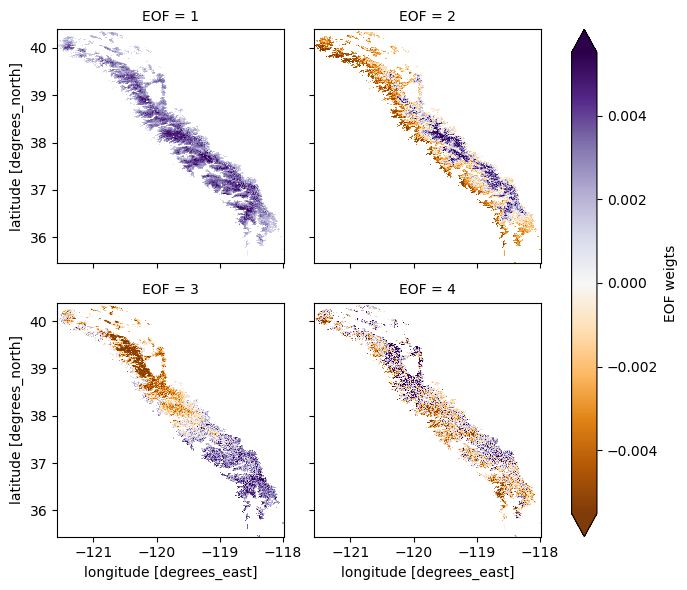

In [17]:
firstFour = U_spatial_eof_mean.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

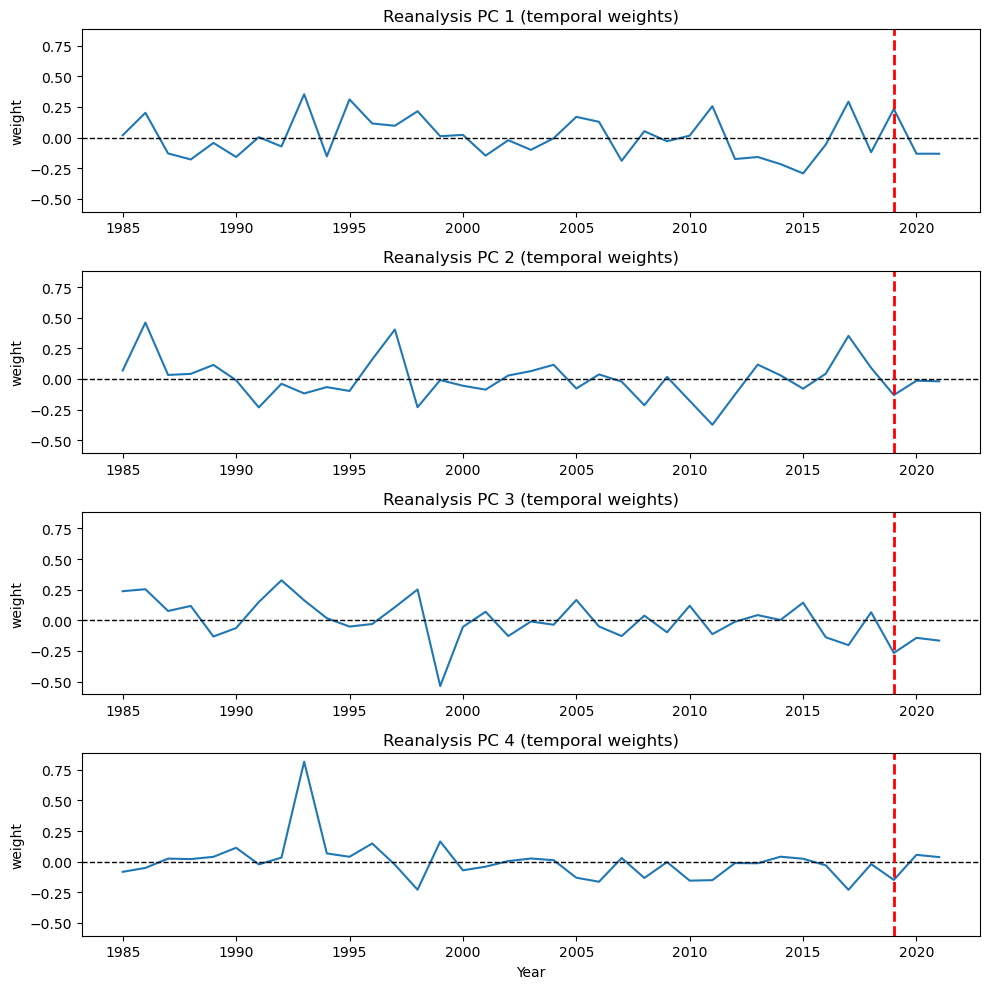

In [26]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_mean[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    ax[row].axhline(0, color='black', linestyle='--', linewidth=1)
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

In [21]:
# SVD Variance Explained, divide S values by the sum of all S
var_exp = S_mean / np.sum(S_mean)

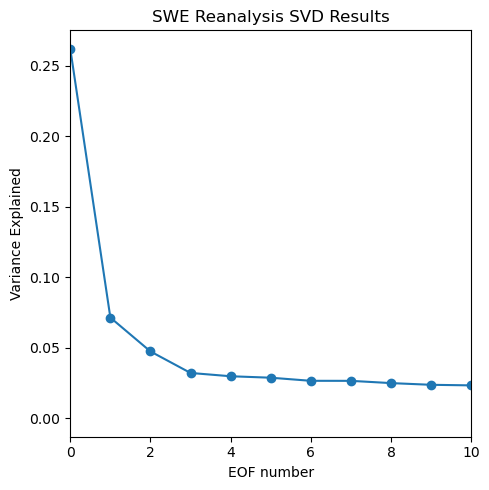

In [22]:
plt.figure(figsize=(5,5))
plt.plot(var_exp,'-o')
plt.xlabel('EOF number')
plt.ylabel('Variance Explained')
#plt.title('SVD Variance Explained')
#plt.ylim([0,0.16])
plt.xlim([0,10])
plt.title('SWE Reanalysis SVD Results')
plt.tight_layout()

In [23]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 3 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:3]),1)), '\nthe top 2 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:2]),1)), '\nthe top 1 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:1]),1)))


Percent of overall variance explained by 
the top 3 patterns = 38.099998474121094% 
the top 2 patterns = 33.29999923706055% 
the top 1 patterns = 26.200000762939453%


## Repeat but for the SWE standardized anomalies without selecting 'snowy' regions:

In [27]:
swe_allyrs_april1_anomalies = (swe_allyrs_april1 - swe_allyrs_april1.mean(dim='time')) / swe_allyrs_april1.std(dim='time')

### Stack the space dimension and remove nan values:

In [28]:
# Stack spatial dimensions into a single 'space' dimension
swe_2d_anom = swe_allyrs_april1_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
swe_2d_clean_anom = swe_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
swe_2d_array_anom = swe_2d_clean_anom.values

### Run the SVD on the standardized anomalies:

In [29]:
U_anom, S_anom, V_anom = svd(swe_2d_array_anom.T, full_matrices=False)

In [ ]:
U_anom.shape

(117133, 37)

### Format the spatial matrix with coordinates:

In [30]:
U_spatial_anom = xr.full_like(swe_2d_clean_anom, np.nan)
U_spatial_anom.values = U_anom.T
U_spatial_unstacked_anom = U_spatial_anom.unstack('space')
U_spatial_unstacked_sorted_anom = U_spatial_unstacked_anom.sortby(['y', 'x'])

### Replace the time coordinate with EOF number:

In [31]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom.sizes['time']
U_spatial_eof_anom = U_spatial_unstacked_sorted_anom.copy()
U_spatial_eof_anom = U_spatial_eof_anom.rename({'time': 'EOF'})
U_spatial_eof_anom = U_spatial_eof_anom.assign_coords(EOF=np.arange(1, n_eof+1))
U_spatial_eof_anom

<xarray.DataArray 'SWE_Post' (EOF: 37, y: 1267, x: 889)> Size: 167MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1267, 889), dtype=float32)
Coordinates:
  * y            (y) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * x            (x) float32 4kB -121.9 -121.8 -121.8 ... -117.9 -117.9 -117.9
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37

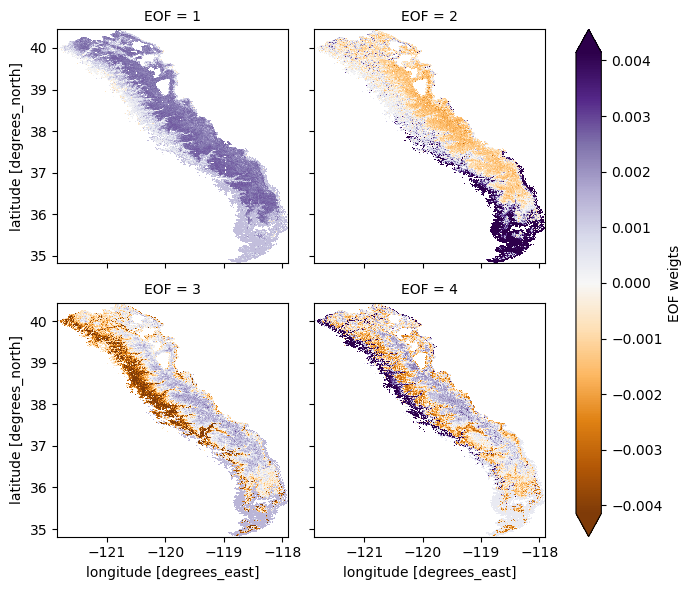

In [32]:
firstFour = U_spatial_eof_anom.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

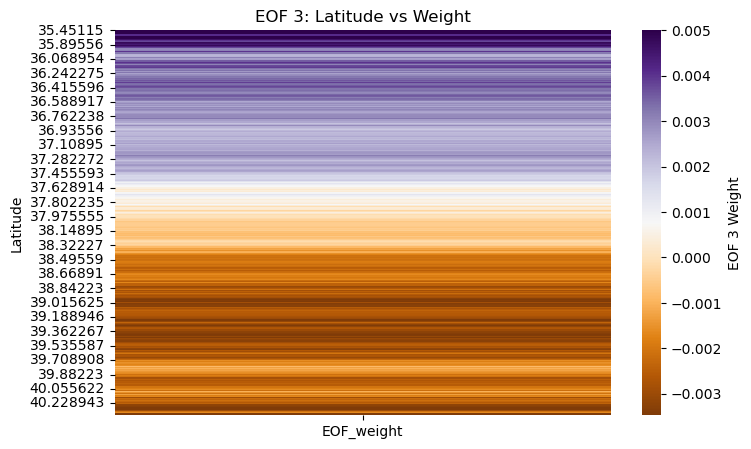

In [ ]:


# Select EOF 3 (Python is 0-indexed, so EOF=3 is index 2)
eof3 = U_spatial_eof_anom.isel(EOF=2)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof3.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='y', values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    cbar_kws={'label': 'EOF 3 Weight'}
)
plt.title('EOF 3: Latitude vs Weight')
plt.ylabel('Latitude')
plt.xlabel('')
plt.show()

In [ ]:
V_anom.shape

(37, 37)

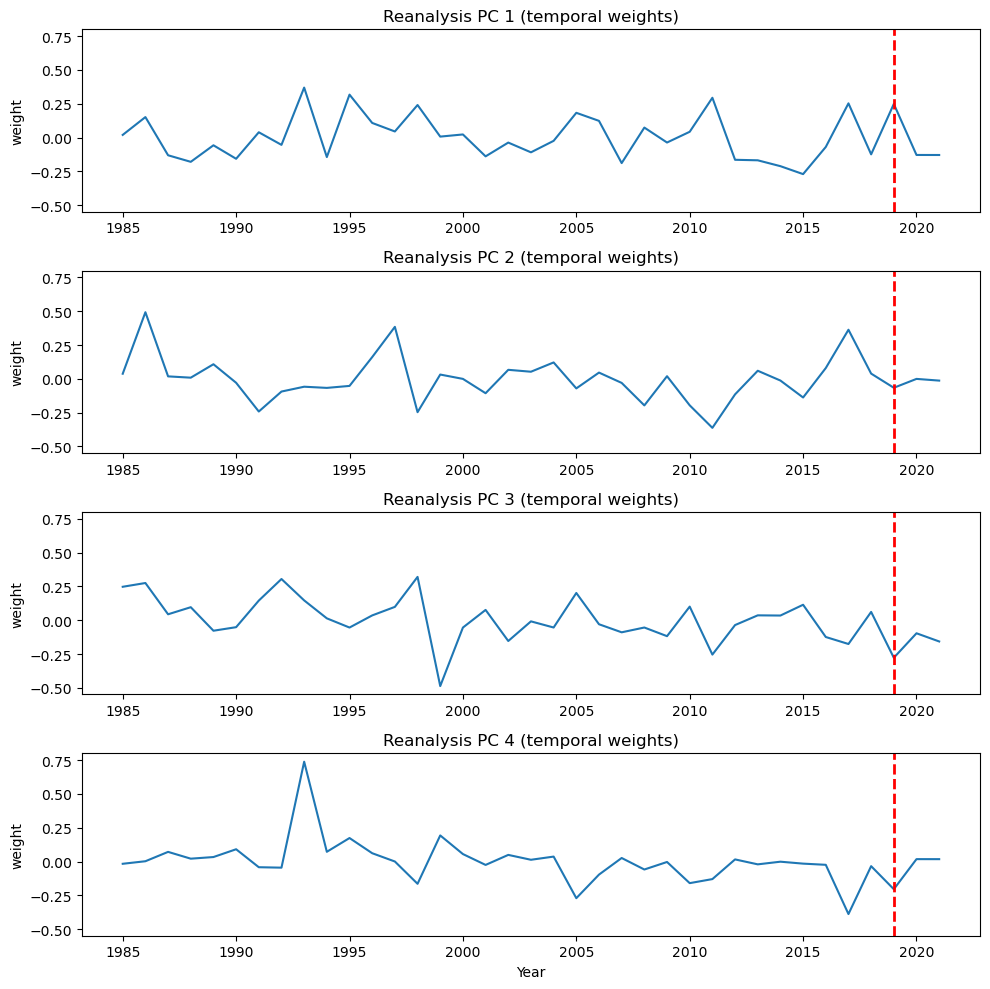

In [ ]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

In [ ]:
# SVD Variance Explained, divide S values by the sum of all S
var_exp = S_anom / np.sum(S_anom)

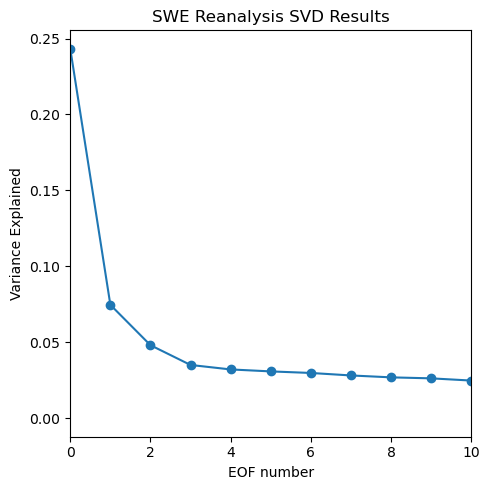

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(var_exp,'-o')
plt.xlabel('EOF number')
plt.ylabel('Variance Explained')
#plt.title('SVD Variance Explained')
#plt.ylim([0,0.16])
plt.xlim([0,10])
plt.title('SWE Reanalysis SVD Results')
plt.tight_layout()

In [ ]:
S_anom.T.shape

(37,)

In [ ]:
S_anom.T

array([1.78120361e+03, 5.46827209e+02, 3.52252441e+02, 2.56910980e+02,
       2.35367889e+02, 2.25874344e+02, 2.18345886e+02, 2.06377670e+02,
       1.97171432e+02, 1.92389893e+02, 1.81732071e+02, 1.75305939e+02,
       1.64936249e+02, 1.59811172e+02, 1.55223679e+02, 1.51857117e+02,
       1.45745499e+02, 1.41941727e+02, 1.34490906e+02, 1.32491333e+02,
       1.25164001e+02, 1.20202835e+02, 1.17926880e+02, 1.13424347e+02,
       1.12117928e+02, 1.10520821e+02, 1.08056633e+02, 1.01746544e+02,
       1.00051743e+02, 9.49952469e+01, 8.97108994e+01, 8.87798843e+01,
       7.95906448e+01, 7.23121872e+01, 6.85465622e+01, 6.29839745e+01,
       3.29494174e-03], dtype=float32)

In [ ]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 3 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:3]),1)), '\nthe top 2 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:2]),1)), '\nthe top 1 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:1]),1)))


Percent of overall variance explained by 
the top 3 patterns = 36.599998474121094% 
the top 2 patterns = 31.799999237060547% 
the top 1 patterns = 24.299999237060547%


## Run on the Standardized anomly of snow depth instead of SWE:

### Get just April 1 of each year from the timeseries:

In [58]:
# 1. Select April 1 of each year
sd_allyrs_april1 = swe_sca_ds_allyrs_sierras.SD_Post.sel(time=( (swe_sca_ds_allyrs_sierras['time'].dt.month == 4) & (swe_sca_ds_allyrs_sierras['time'].dt.day == 1) )).compute()

In [59]:
sd_allyrs_april1_snowy = sd_allyrs_april1.where(sd_allyrs_april1.mean(dim='time') > 0.1)

In [60]:
sd_allyrs_april1_snowy_anomalies = (sd_allyrs_april1_snowy - sd_allyrs_april1_snowy.mean(dim='time')) / sd_allyrs_april1_snowy.std(dim='time')

### Stack the space dimension and remove nan values:

In [61]:
# Stack spatial dimensions into a single 'space' dimension
sd_2d_anom = sd_allyrs_april1_snowy_anomalies.stack(space=('y', 'x'))

# Optionally, drop all spatial points (columns) that have any NaNs across time
sd_2d_clean_anom = sd_2d_anom.dropna(dim='space', how='any')

# Convert to a numpy 2D array: shape will be (time, space)
sd_2d_array_anom = sd_2d_clean_anom.values

In [63]:
sd_2d_anom

<xarray.DataArray 'SD_Post' (time: 37, space: 1164373)> Size: 172MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(37, 1164373), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0
  * space        (space) object 9MB MultiIndex
  * y            (space) float32 5MB 34.82 34.82 34.82 ... 40.45 40.45 40.45
  * x            (space) float32 5MB -121.9 -121.9 -121.9 ... -117.9 -117.9

### Run the SVD on the standardized anomalies:

In [66]:
U_anom_sd, S_anom_sd, V_anom_sd = svd(sd_2d_array_anom.T, full_matrices=False)

In [67]:
U_anom_sd.shape

(144300, 37)

In [68]:
U_anom.shape

(117133, 37)

In [ ]:
S_anom.shape

(37,)

In [ ]:
V_anom.shape

(37, 37)

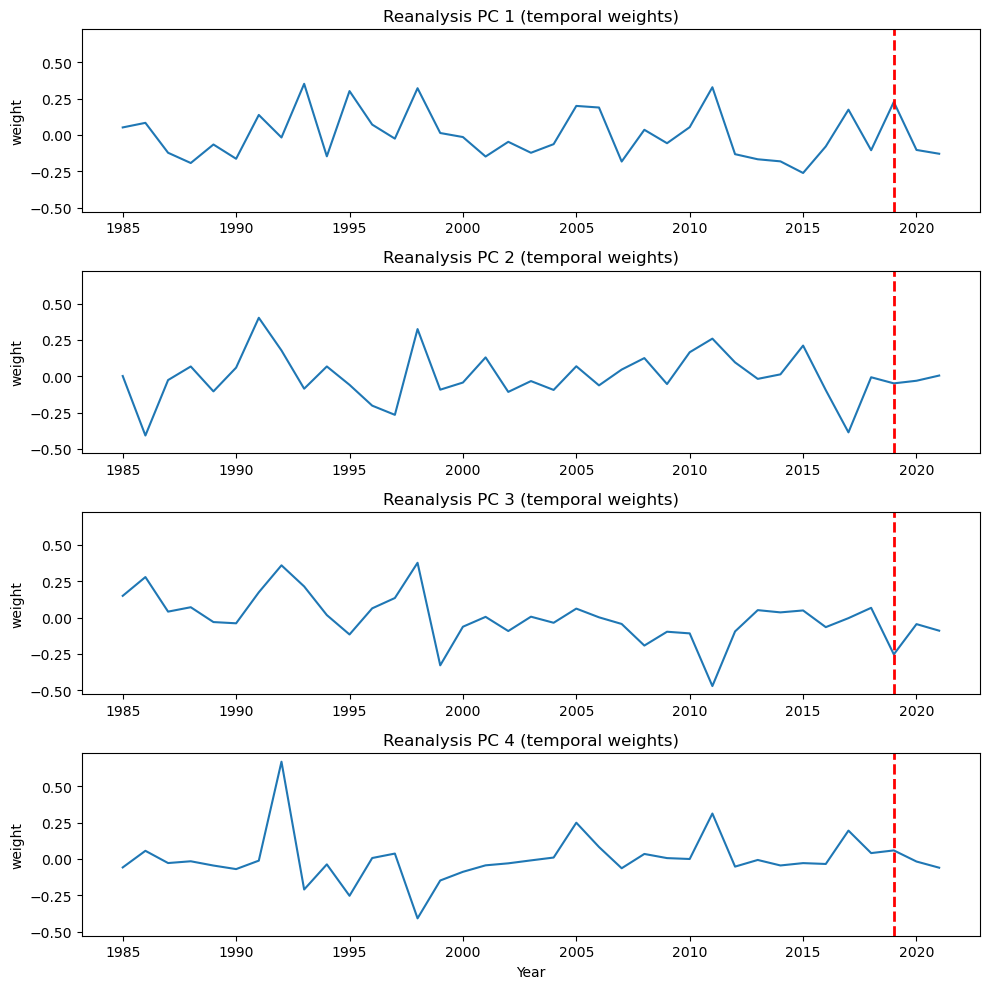

In [69]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom_sd[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

### Format the spatial matrix with coordinates:

In [70]:
U_spatial_anom_sd = xr.full_like(sd_2d_clean_anom, np.nan)
U_spatial_anom_sd.values = U_anom_sd.T
U_spatial_unstacked_anom_sd = U_spatial_anom_sd.unstack('space')
U_spatial_unstacked_sorted_anom_sd = U_spatial_unstacked_anom_sd.sortby(['y', 'x'])

In [ ]:
# U_spatial_anom = xr.full_like(swe_2d_clean_anom.T, np.nan)
# U_spatial_anom.values = U_anom
# U_spatial_unstacked_anom = U_spatial_anom.unstack('space')
# U_spatial_unstacked_sorted_anom = U_spatial_unstacked_anom.sortby(['y', 'x'])

In [ ]:
U_spatial_unstacked_sorted_anom

<xarray.DataArray 'SWE_Post' (time: 37, y: 1047, x: 796)> Size: 123MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1047, 796), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.45 35.46 35.46 35.46 ... 40.38 40.38 40.39
  * x            (x) float32 3kB -121.6 -121.6 -121.6 ... -118.0 -118.0 -118.0
  * time         (time) datetime64[ns] 296B 1985-04-01 1986-04-01 ... 2021-04-01
    spatial_ref  int64 8B 0

### Replace the time coordinate with EOF number:

In [71]:
# Replace the 'time' dimension with 'EOF' (1 to N), preserving order
n_eof = U_spatial_unstacked_sorted_anom_sd.sizes['time']
U_spatial_eof_anom_sd = U_spatial_unstacked_sorted_anom_sd.copy()
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.rename({'time': 'EOF'})
U_spatial_eof_anom_sd = U_spatial_eof_anom_sd.assign_coords(EOF=np.arange(1, n_eof+1))
U_spatial_eof_anom_sd

<xarray.DataArray 'SD_Post' (EOF: 37, y: 1099, x: 819)> Size: 133MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(37, 1099, 819), dtype=float32)
Coordinates:
  * y            (y) float32 4kB 35.01 35.02 35.02 35.03 ... 40.41 40.42 40.44
  * x            (x) float32 3kB -121.7 -121.6 -121.6 ... -118.0 -118.0 -118.0
    spatial_ref  int64 8B 0
  * EOF          (EOF) int64 296B 1 2 3 4 5 6 7 8 9 ... 30 31 32 33 34 35 36 37

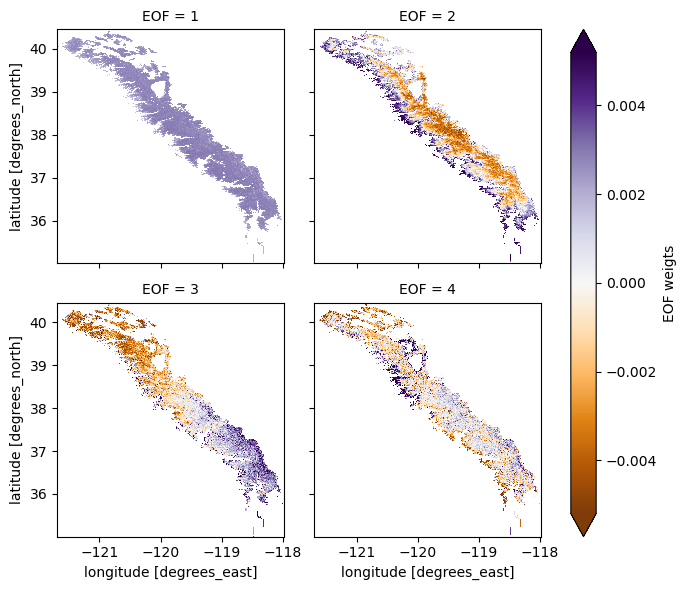

In [72]:
firstFour = U_spatial_eof_anom_sd.isel(EOF=slice(0, 4)).copy()

g = firstFour.plot.pcolormesh(
    x="x",
    y="y",
    col="EOF",
    col_wrap=2,
    robust=True,
    cmap="PuOr",
    cbar_kwargs={"label": "EOF weigts"},
)

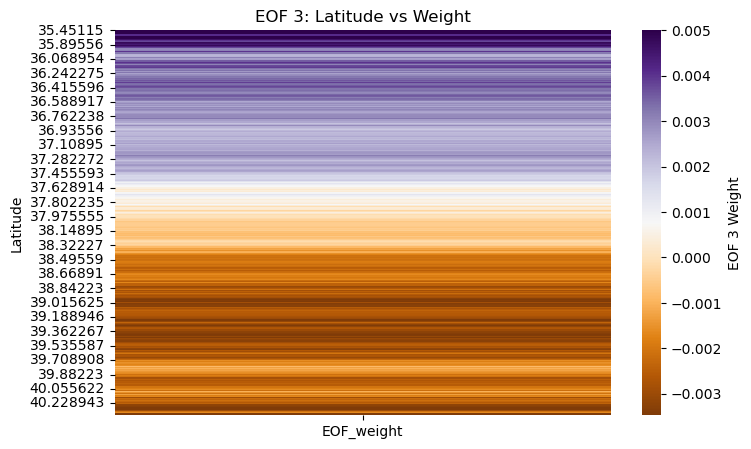

In [ ]:


# Select EOF 3 (Python is 0-indexed, so EOF=3 is index 2)
eof3 = U_spatial_eof_anom.isel(EOF=2)

# Prepare data for seaborn: flatten to DataFrame with latitude (y) and weight
df = eof3.to_dataframe(name='EOF_weight').reset_index()

# Plot heatmap of latitude vs EOF weight
plt.figure(figsize=(8, 5))
sns.heatmap(
    df.pivot_table(index='y', values='EOF_weight'),
    cmap='PuOr',
    robust=True,
    cbar_kws={'label': 'EOF 3 Weight'}
)
plt.title('EOF 3: Latitude vs Weight')
plt.ylabel('Latitude')
plt.xlabel('')
plt.show()

In [ ]:
V_anom.shape

(37, 37)

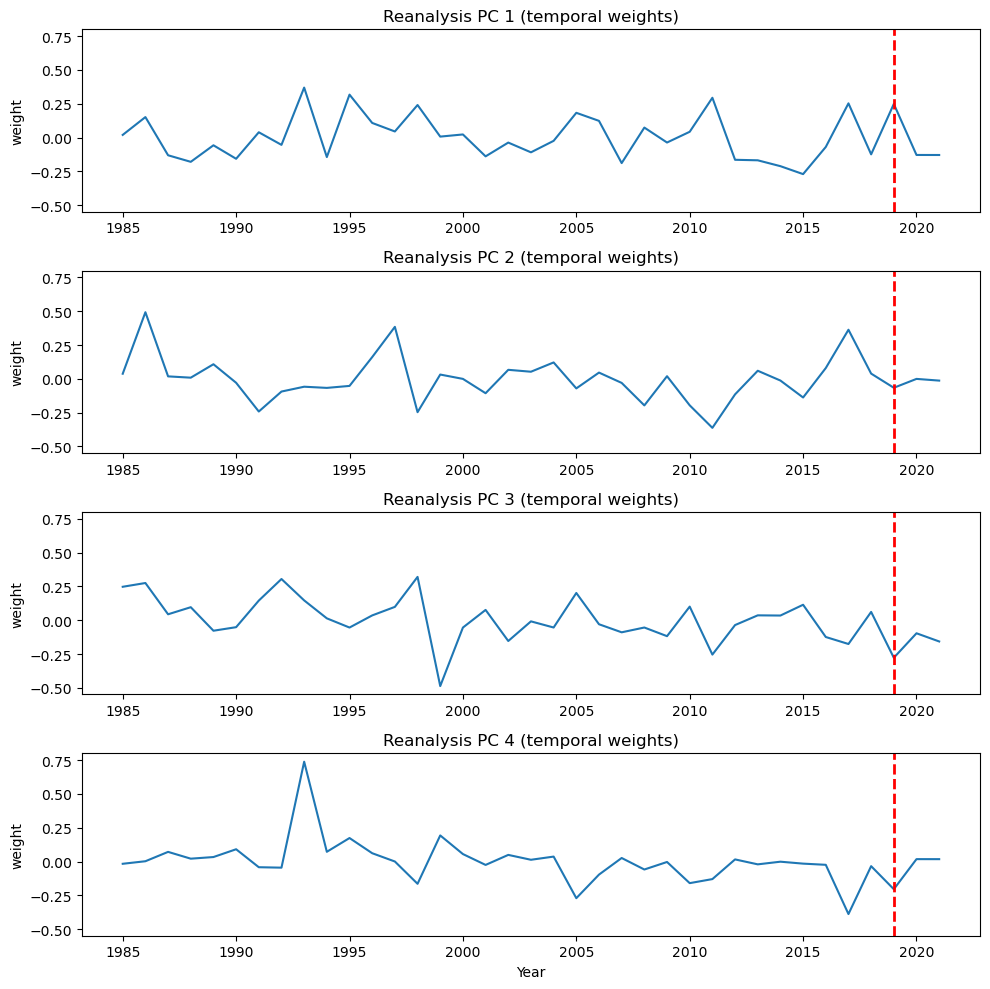

In [ ]:
#Plot first PC (V)
f, ax = plt.subplots(4,1, sharex=False, sharey=True, figsize=(10,10))
i=0
for row in range(4): 
    ax[row].plot(np.linspace(1985, 2021, num=37, dtype=int),V_anom[i,:])
    ax[row].set_ylabel('weight')
    ax[row].set_title(f'Reanalysis PC {i+1} (temporal weights)')
    i+=1

ax[3].set_xlabel('Year')

for ax in plt.gcf().axes:
    ax.axvline(2019, color='red', linestyle='--', linewidth=2)

plt.tight_layout()

In [ ]:
# SVD Variance Explained, divide S values by the sum of all S
var_exp = S_anom / np.sum(S_anom)

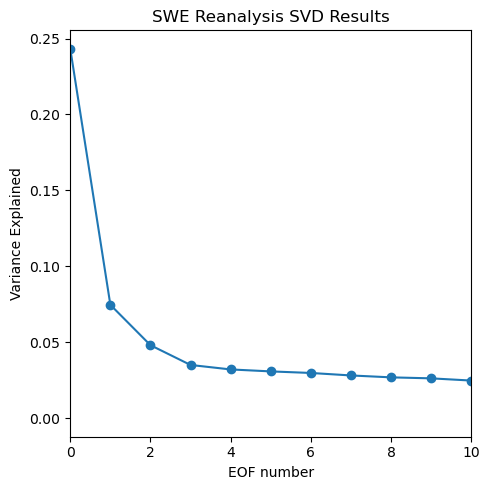

In [ ]:
plt.figure(figsize=(5,5))
plt.plot(var_exp,'-o')
plt.xlabel('EOF number')
plt.ylabel('Variance Explained')
#plt.title('SVD Variance Explained')
#plt.ylim([0,0.16])
plt.xlim([0,10])
plt.title('SWE Reanalysis SVD Results')
plt.tight_layout()

In [ ]:
S_anom.T.shape

(37,)

In [ ]:
S_anom.T

array([1.78120361e+03, 5.46827209e+02, 3.52252441e+02, 2.56910980e+02,
       2.35367889e+02, 2.25874344e+02, 2.18345886e+02, 2.06377670e+02,
       1.97171432e+02, 1.92389893e+02, 1.81732071e+02, 1.75305939e+02,
       1.64936249e+02, 1.59811172e+02, 1.55223679e+02, 1.51857117e+02,
       1.45745499e+02, 1.41941727e+02, 1.34490906e+02, 1.32491333e+02,
       1.25164001e+02, 1.20202835e+02, 1.17926880e+02, 1.13424347e+02,
       1.12117928e+02, 1.10520821e+02, 1.08056633e+02, 1.01746544e+02,
       1.00051743e+02, 9.49952469e+01, 8.97108994e+01, 8.87798843e+01,
       7.95906448e+01, 7.23121872e+01, 6.85465622e+01, 6.29839745e+01,
       3.29494174e-03], dtype=float32)

In [ ]:
# sum of the first 10
print('Percent of overall variance explained by \nthe top 3 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:3]),1)), '\nthe top 2 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:2]),1)), '\nthe top 1 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:1]),1)), '\nthe top 10 patterns = {}%'.format( np.round( 100*np.sum(var_exp[0:10]),1)))


Percent of overall variance explained by 
the top 3 patterns = 36.599998474121094% 
the top 2 patterns = 31.799999237060547% 
the top 1 patterns = 24.299999237060547% 
the top 10 patterns = 57.5%
